In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense
)

In [3]:
dataset_path = "/content/drive/MyDrive/dataset_dl_lab/coco128"

image_dir = os.path.join(dataset_path, "images/train2017")

label_dir = os.path.join(dataset_path, "labels/train2017")

In [4]:
print(len(os.listdir(image_dir)))

print(len(os.listdir(label_dir)))

128
128


In [5]:
IMG_SIZE = 128

In [6]:
images = []

classes = []

bboxes = []

In [7]:
image_files = os.listdir(image_dir)

for img_file in image_files:

    image_path = os.path.join(image_dir, img_file)

    label_file = img_file.replace(".jpg", ".txt")

    label_path = os.path.join(label_dir, label_file)

    # Read image
    image = cv2.imread(image_path)

    if image is None:
        continue

    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

    image = image / 255.0

    # Read label
    if os.path.exists(label_path):

        with open(label_path, "r") as f:

            lines = f.readlines()

            if len(lines) == 0:
                continue

            # Take first object only
            line = lines[0].strip().split()

            class_id = int(line[0])

            x_center = float(line[1])

            y_center = float(line[2])

            width = float(line[3])

            height = float(line[4])

            images.append(image)

            classes.append(class_id)

            bboxes.append(
                [x_center, y_center, width, height]
            )

In [8]:
images = np.array(images, dtype="float32")

classes = np.array(classes)

bboxes = np.array(bboxes, dtype="float32")

In [9]:
print(images.shape)

print(classes.shape)

print(bboxes.shape)

(126, 128, 128, 3)
(126,)
(126, 4)


In [10]:
X_train, X_test, y_train, y_test, bbox_train, bbox_test = train_test_split(
    images,
    classes,
    bboxes,
    test_size=0.2,
    random_state=42
)

In [11]:
input_layer = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = Conv2D(32, (3,3), activation='relu')(input_layer)

x = MaxPooling2D(2,2)(x)

x = Conv2D(64, (3,3), activation='relu')(x)

x = MaxPooling2D(2,2)(x)

x = Conv2D(128, (3,3), activation='relu')(x)

x = MaxPooling2D(2,2)(x)

x = Flatten()(x)

x = Dense(256, activation='relu')(x)

# Classification output
class_output = Dense(
    80,
    activation='softmax',
    name='class_output'
)(x)

# Bounding box output
bbox_output = Dense(
    4,
    activation='sigmoid',
    name='bbox_output'
)(x)

model = Model(
    inputs=input_layer,
    outputs=[class_output, bbox_output]
)

In [12]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 126, 126,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 63, 63,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 61, 61,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 30, 30,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 28, 28,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 14, 14,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 25088)     │          0 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  6,422,784 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_output        │ (None, 80)        │     20,560 │ dense[0][0]       │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bbox_output (Dense) │ (None, 4)         │      1,028 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,537,620 (24.94 MB)

 Trainable params: 6,537,620 (24.94 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer='adam',

    loss={
        'class_output': 'sparse_categorical_crossentropy',
        'bbox_output': 'mse'
    },

    metrics={
        'class_output': 'accuracy',
        'bbox_output': 'mse'
    }
)

In [24]:
history = model.fit(
    X_train,

    {
        'class_output': y_train,
        'bbox_output': bbox_train
    },

    validation_data=(
        X_test,
        {
            'class_output': y_test,
            'bbox_output': bbox_test
        }
    ),

    epochs=50,
    batch_size=16
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - bbox_output_loss: 0.0071 - bbox_output_mse: 0.0077 - class_output_accuracy: 1.0000 - class_output_loss: 8.4788e-04 - loss: 0.0085 - val_bbox_output_loss: 0.1090 - val_bbox_output_mse: 0.1138 - val_class_output_accuracy: 0.1154 - val_class_output_loss: 13.0960 - val_loss: 13.2731
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - bbox_output_loss: 0.0069 - bbox_output_mse: 0.0075 - class_output_accuracy: 1.0000 - class_output_loss: 8.8742e-04 - loss: 0.0083 - val_bbox_output_loss: 0.1121 - val_bbox_output_mse: 0.1176 - val_class_output_accuracy: 0.1154 - val_class_output_loss: 13.1421 - val_loss: 13.3197
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - bbox_output_loss: 0.0062 - bbox_output_mse: 0.0067 - class_output_accuracy: 1.0000 - class_output_loss: 8.1175e-04 - loss: 0.0074 - val_bbox_output_loss: 0.1059 - val_bbox_output_mse: 0.1098 - val_class_output_accuracy: 0.1154 - val_class_output_loss: 13.2495 - val_loss: 13.4196
Epoch 4

In [25]:
pred_class, pred_bbox = model.predict(X_test[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


In [26]:
print("Predicted Class:")

print(np.argmax(pred_class))

print()

print("Predicted Bounding Box:")

print(pred_bbox)

Predicted Class:
16

Predicted Bounding Box:
[[0.71669346 0.5005221  0.06317707 0.1252873 ]]


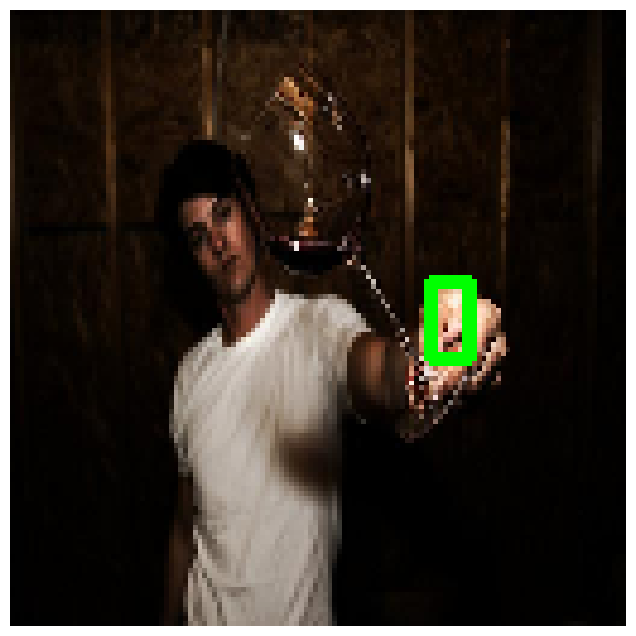

In [27]:
image = X_test[1].copy()

h, w, _ = image.shape

x_center = pred_bbox[0][0] * w

y_center = pred_bbox[0][1] * h

box_width = pred_bbox[0][2] * w

box_height = pred_bbox[0][3] * h

xmin = int(x_center - box_width/2)

ymin = int(y_center - box_height/2)

xmax = int(x_center + box_width/2)

ymax = int(y_center + box_height/2)

image = (image * 255).astype("uint8")

cv2.rectangle(
    image,
    (xmin, ymin),
    (xmax, ymax),
    (0,255,0),
    2
)

plt.figure(figsize=(8,8))

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

plt.axis("off")

plt.show()